# COMP 3608 Project Notebook  

Organization:

- **three datasets**
- **three algorithms**
- **feature analysis**
- **experimental design**


### Project goal
The goal is to compare how three machine learning approaches behave on three datasets, and explain the strengths, weaknesses, and tradeoffs of each method.

For each dataset, the target variable has two classes:

- non-fraud
- fraud

### Algorithms selected
- Logistic Regression

- Random Forest

- XGBoost

### Why these three?
Together they create a meaningful comparison:

- Simple linear model
- Bagging-based tree ensemble
- Boosting-based tree ensemble

### Datasets used
This notebook uses three fraud-related datasets supplied for the project:

1. `creditcard.csv`: https://www.kaggle.com/datasets/jainilcoder/online-payment-fraud-detection?resource=downloaddata
2. `onlinefraud.csv`: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data
3. `Base.csv`: https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022/data?select=Base.csv


These three datasets represent different fraud settings and feature structures, which helps test whether the models behave consistently or differently depending on the data.

## Imports

In [ ]:
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")


from xgboost import XGBClassifier


## Load datasets

In [ ]:
files = [
    "/mnt/data/archive (3).zip",
    "/mnt/data/archive (2).zip",
    "/mnt/data/archive (5).zip",
]

EXTRACT_DIR = "./project_data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

for zip_path in files:
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(EXTRACT_DIR)

print("Extracted files:")
for name in sorted(os.listdir(EXTRACT_DIR)):
    print("-", name)

Extracted files:


## Set target column

In [ ]:
DATASETS = {
    "Credit Card Fraud": {
        "path": os.path.join(EXTRACT_DIR, "creditcard.csv"),
        "target": "Class"
    },
    "Online Payment Fraud": {
        "path": os.path.join(EXTRACT_DIR, "onlinefraud.csv"),
        "target": "isFraud"
    },
    "Bank Account Application Fraud": {
        "path": os.path.join(EXTRACT_DIR, "Base.csv"),
        "target": "fraud_bool"
    }
}

for dataset_name, info in DATASETS.items():
    print(dataset_name, "->", info["path"], "| target =", info["target"])

Credit Card Fraud -> ./project_data\creditcard.csv | target = Class
Online Payment Fraud -> ./project_data\onlinefraud.csv | target = isFraud
Bank Account Application Fraud -> ./project_data\Base.csv | target = fraud_bool


## Helper Functions

In [ ]:
def load_dataset(path):
    df = pd.read_csv(path)
    return df


def basic_overview(df, dataset_name, target_col):
    print("Dataset:", dataset_name)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(list(df.columns))
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nMissing values per column:")
    display(df.isnull().sum().sort_values(ascending=False).head(15))
    print("\nTarget distribution (counts):")
    display(df[target_col].value_counts(dropna=False))
    print("\nTarget distribution (%):")
    display((df[target_col].value_counts(normalize=True) * 100).round(4))

In [ ]:
def plot_class_distribution(df, target_col, dataset_name):
    counts = df[target_col].value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar")
    plt.title(f"{dataset_name} - Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

In [ ]:
def get_feature_lists(df, target_col):
    X = df.drop(columns=[target_col])
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
    return numeric_cols, categorical_cols

In [ ]:
def plot_top_numeric_correlations(df, target_col, dataset_name, top_n=10):
    numeric_df = df.select_dtypes(include=["number"]).copy()
    if target_col not in numeric_df.columns:
        print("Target is not numeric, correlation plot skipped.")
        return

    corr = numeric_df.corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
    top_corr = corr.head(top_n)

    if len(top_corr) == 0:
        print("No numeric features available for correlation plot.")
        return

    plt.figure(figsize=(8, 5))
    top_corr.sort_values().plot(kind="barh")
    plt.title(f"{dataset_name} - Top Numeric Features by Correlation with {target_col}")
    plt.xlabel("Correlation")
    plt.ylabel("Feature")
    plt.show()

    display(top_corr.to_frame("correlation_with_target"))

In [ ]:
def plot_top_skewed_features(df, target_col, dataset_name, top_n=8):
    numeric_df = df.select_dtypes(include=["number"]).drop(columns=[target_col], errors="ignore")
    if numeric_df.shape[1] == 0:
        print("No numeric features available for skew analysis.")
        return

    skewness = numeric_df.skew(numeric_only=True).sort_values(key=np.abs, ascending=False)
    top_skew = skewness.head(top_n)

    plt.figure(figsize=(8, 5))
    top_skew.sort_values().plot(kind="barh")
    plt.title(f"{dataset_name} - Most Skewed Numeric Features")
    plt.xlabel("Skewness")
    plt.ylabel("Feature")
    plt.show()

    display(top_skew.to_frame("skewness"))

In [ ]:
def plot_numeric_feature_by_class(df, target_col, dataset_name, feature_name):
    if feature_name not in df.columns:
        print("Feature not found:", feature_name)
        return

    clean_df = df[[feature_name, target_col]].dropna().copy()
    classes = sorted(clean_df[target_col].unique())

    plt.figure(figsize=(8, 4))
    for class_value in classes:
        series = clean_df.loc[clean_df[target_col] == class_value, feature_name]
        plt.hist(series, bins=40, alpha=0.5, label=f"class={class_value}")
    plt.title(f"{dataset_name} - Distribution of {feature_name} by Class")
    plt.xlabel(feature_name)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [ ]:
def show_top_categorical_fraud_rates(df, target_col, dataset_name, top_n=10):
    categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

    if len(categorical_cols) == 0:
        print("No categorical features available.")
        return

    for col in categorical_cols[:5]:
        print(f"\n{dataset_name} - Fraud rate by {col}")
        temp = df.groupby(col)[target_col].mean().sort_values(ascending=False).head(top_n)
        display(temp.to_frame("fraud_rate"))
        plt.figure(figsize=(8, 4))
        temp.sort_values().plot(kind="barh")
        plt.title(f"{dataset_name} - Top Fraud Rates by {col}")
        plt.xlabel("Fraud rate")
        plt.ylabel(col)
        plt.show()

In [ ]:
def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    X_processed = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    return X_processed, numeric_cols, categorical_cols

In [ ]:
def preprocess_for_model(df, target_col):
    df = df.copy()

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # simple one-hot encoding for categorical columns
    X = pd.get_dummies(X, drop_first=True)

    # fill missing numeric values with median
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    numeric_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()

    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test

In [ ]:
def get_models():
    models = {}

    models["Logistic Regression"] = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    models["Random Forest"] = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    models["XGBoost"] = XGBClassifier(
          n_estimators=200,
          max_depth=6,
          learning_rate=0.1,
          subsample=0.8,
          colsample_bytree=0.8,
          eval_metric="logloss",
          random_state=42
    )


    return models

In [ ]:
def train_and_evaluate_models(X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, dataset_name):
    models = get_models()
    rows = []
    fitted_models = {}

    for model_name, model in models.items():
        if model_name == "Logistic Regression":
            train_X = X_train_scaled
            test_X = X_test_scaled
        else:
            train_X = X_train
            test_X = X_test

        model.fit(train_X, y_train)

        y_pred = model.predict(test_X)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(test_X)[:, 1]
        else:
            y_prob = None

        result = {
            "dataset": dataset_name,
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
        }

        rows.append(result)
        fitted_models[model_name] = {
            "model": model,
            "y_pred": y_pred,
            "y_prob": y_prob
        }

    results_df = pd.DataFrame(rows).sort_values(by="f1", ascending=False)
    return results_df, fitted_models

In [ ]:
def plot_confusion_matrices(fitted_models, X_test, X_test_scaled, y_test, dataset_name):
    for model_name, obj in fitted_models.items():
        model = obj["model"]
        y_pred = obj["y_pred"]

        plt.figure(figsize=(5, 4))
        disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
        disp.plot()
        plt.title(f"{dataset_name} - {model_name} Confusion Matrix")
        plt.show()

In [ ]:
def plot_feature_importance(model, feature_names, dataset_name, model_name, top_n=15):
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
        plt.figure(figsize=(8, 5))
        importances.sort_values().plot(kind="barh")
        plt.title(f"{dataset_name} - {model_name} Feature Importance")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.show()
        display(importances.to_frame("importance"))

    elif hasattr(model, "coef_"):
        coef = pd.Series(model.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False).head(top_n)
        plt.figure(figsize=(8, 5))
        coef.sort_values().plot(kind="barh")
        plt.title(f"{dataset_name} - {model_name} Largest Logistic Coefficients")
        plt.xlabel("Coefficient")
        plt.ylabel("Feature")
        plt.show()
        display(coef.to_frame("coefficient"))

    else:
        print("Feature importance not available for", model_name)

## Evaluating dataset 1: Credit Card Fraud Dataset

The Credit Card Fraud dataset consists primarily of anonymized numerical features labeled V1 through V28, along with additional variables including Time, Amount, and a binary target variable Class indicating fraudulent or non-fraudulent transactions. The values and features had been anonimized and tranformed.
Most features are already in a numeric format, which reduces the need for extensive preprocessing such as encoding categorical variables. However, the dataset is highly imbalanced, with fraudulent transactions representing a very small proportion of the total observations. As a result, standard evaluation metrics such as accuracy are not sufficient for assessing model performance. Instead, metrics such as recall and F1-score are more appropriate, as they better capture the model's ability to correctly identify fraudulent cases while accounting for the imbalance in class distribution.

DATASET: Credit Card Fraud
Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Missing values per column:


Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
V10     0
V11     0
V12     0
V13     0
V14     0
dtype: int64


Target distribution (counts):


Class
0    284315
1       492
Name: count, dtype: int64


Target distribution (%):


Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64

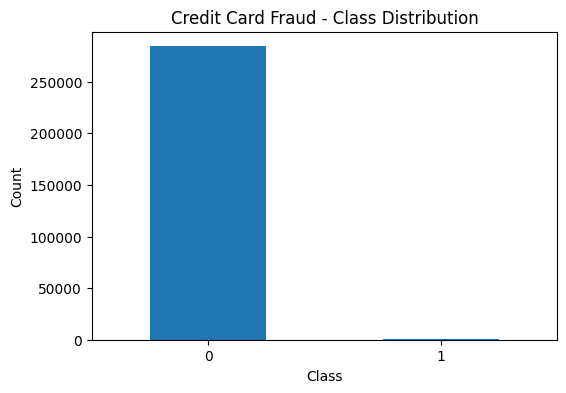

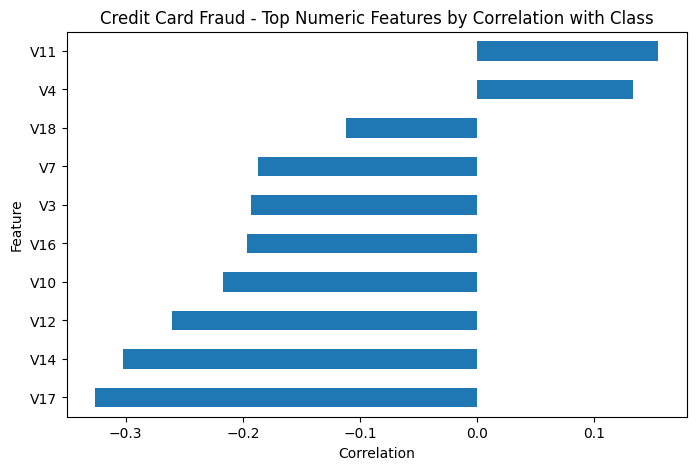

,correlation_with_target
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


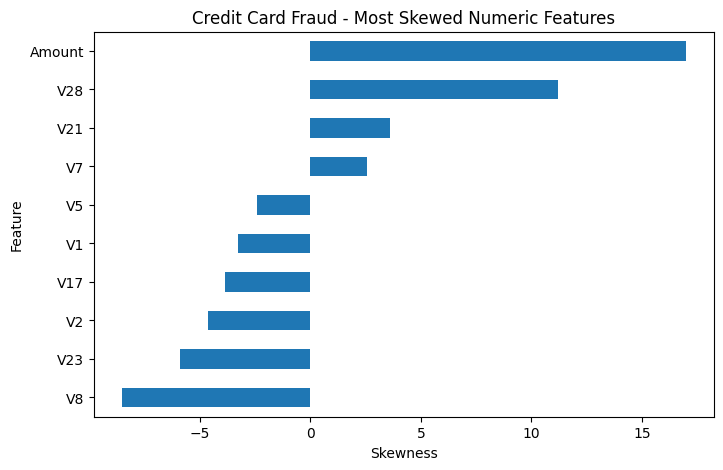

,skewness
Amount,16.977724
V28,11.192091
V8,-8.521944
V23,-5.875140
V2,-4.624866
V17,-3.844914
V21,3.592991
V1,-3.280667
V7,2.553907
V5,-2.425901


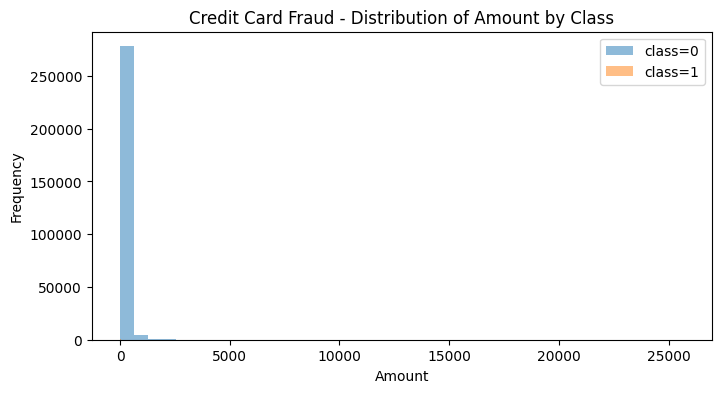

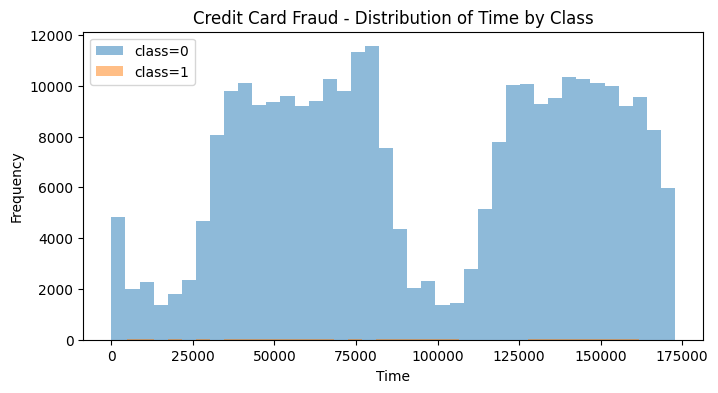

In [ ]:
credit_info = DATASETS["Credit Card Fraud"]
credit_df = load_dataset(credit_info["path"])
basic_overview(credit_df, "Credit Card Fraud", credit_info["target"])
plot_class_distribution(credit_df, credit_info["target"], "Credit Card Fraud")
plot_top_numeric_correlations(credit_df, credit_info["target"], "Credit Card Fraud", top_n=10)
plot_top_skewed_features(credit_df, credit_info["target"], "Credit Card Fraud", top_n=10)
plot_numeric_feature_by_class(credit_df, credit_info["target"], "Credit Card Fraud", "Amount")
plot_numeric_feature_by_class(credit_df, credit_info["target"], "Credit Card Fraud", "Time")

### Credit Card Fraud Dataset Interpretation

The class distribution indicates that fraudulent transactions are extremely rare compared to non-fraudulent ones. The count of class 1 observations is negligible relative to class 0, confirming a severe class imbalance. This has a direct impact on modelling, as standard accuracy would be misleading; models must instead prioritize recall and F1-score to ensure that the minority fraud cases are not ignored. The distribution of the Amount feature shows strong positive skewness, with a long right tail. This suggests that while most transactions are of relatively low value, a small number of transactions have very large amounts. Such skewness can negatively affect models that assume normally distributed inputs, indicating that transformations such as log scaling may improve performance and stability. The time-based distribution shows significant overlap between fraudulent and non-fraudulent transactions. Fraud cases do not appear to occur in a clearly separable time window, but rather are distributed across similar time ranges as normal transactions. This implies that Time alone is not a strong discriminative feature and that the model must rely on combinations of other variables to distinguish between classes. From the correlation analysis, anonymized variables such as V17, V14, V12, V10, and V16 show the strongest negative relationships with the target, while V11 and V4 show the strongest positive relationships. These features are likely to contribute most to class separation. However, since these variables are transformed and lack direct interpretability, their usefulness is primarily statistical rather than domain-driven.

The feature behavior suggests that a simple linear boundary may not be sufficient to fully separate fraudulent and non-fraudulent transactions. The overlap between classes and the reliance on multiple transformed features indicate that the underlying patterns are likely non-linear and complex. This supports the use of more flexible models such as Random Forest or Gradient Boosting, which can capture interactions and non-linear relationships more effectively than basic linear models.

,dataset,model,accuracy,precision,recall,f1,roc_auc
2,Credit Card Fraud,XGBoost,0.999579,0.940476,0.806122,0.868132,0.979476
1,Credit Card Fraud,Random Forest,0.999526,0.961039,0.755102,0.845714,0.957189
0,Credit Card Fraud,Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972083


<Figure size 500x400 with 0 Axes>

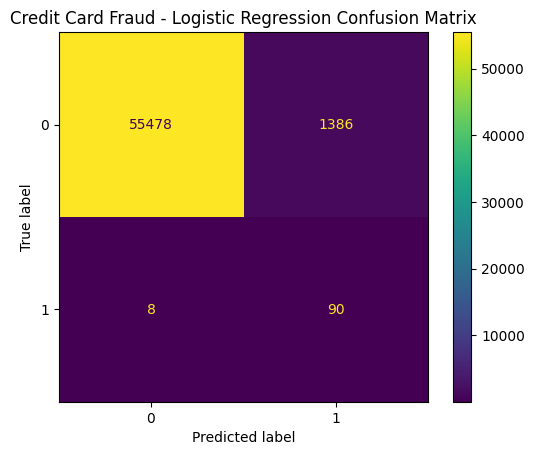

<Figure size 500x400 with 0 Axes>

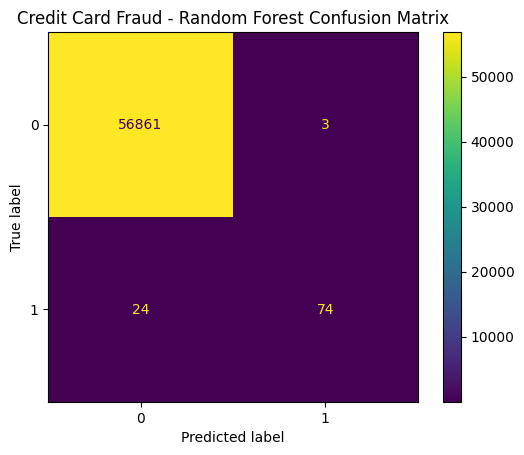

<Figure size 500x400 with 0 Axes>

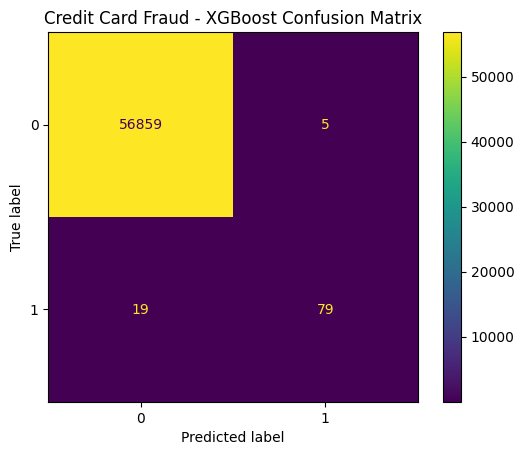

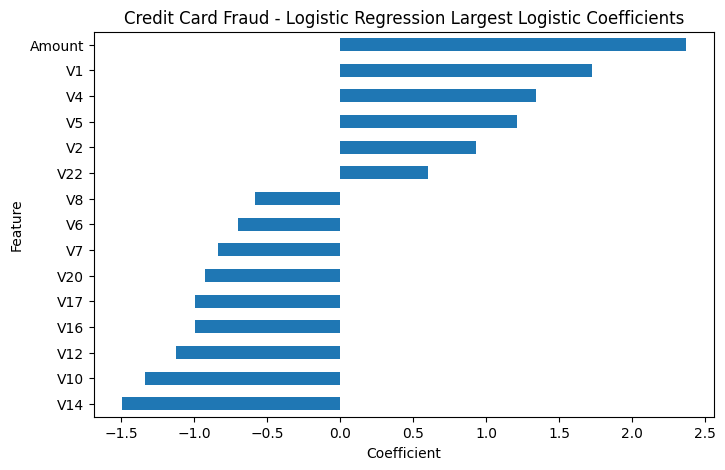

,coefficient
Amount,2.367276
V1,1.723862
V14,-1.494961
V4,1.339431
V10,-1.334996
V5,1.214379
V12,-1.127886
V16,-0.996376
V17,-0.992185
V2,0.932075


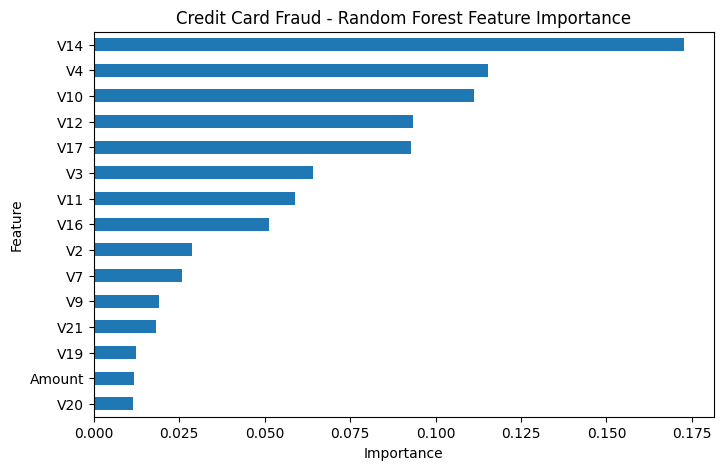

,importance
V14,0.172755
V4,0.115382
V10,0.111231
V12,0.093417
V17,0.092719
V3,0.064234
V11,0.058795
V16,0.051311
V2,0.028824
V7,0.025840


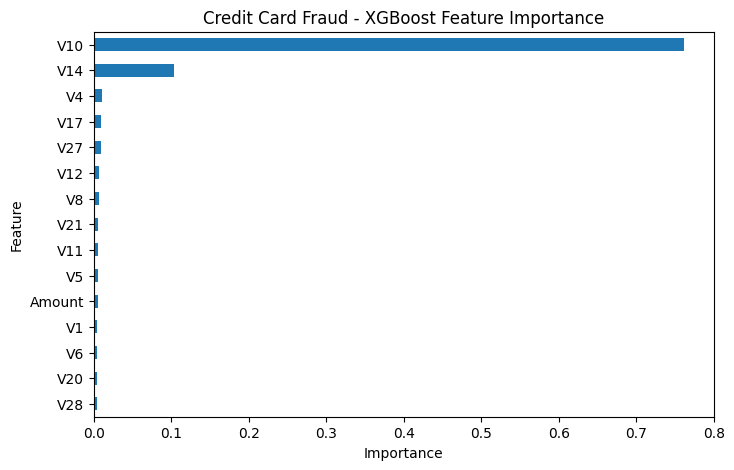

,importance
V10,0.762089
V14,0.103587
V4,0.010560
V17,0.008942
V27,0.008898
V12,0.007044
V8,0.006243
V21,0.005676
V11,0.005201
V5,0.005082


In [ ]:
X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = preprocess_for_model(credit_df, credit_info["target"])
credit_results, credit_models = train_and_evaluate_models(
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, "Credit Card Fraud"
)
display(credit_results)
plot_confusion_matrices(credit_models, X_test, X_test_scaled, y_test, "Credit Card Fraud")

for model_name, obj in credit_models.items():
    plot_feature_importance(obj["model"], X_train.columns, "Credit Card Fraud", model_name, top_n=15)

### Credit Card Fraud Model Evaluation

From the confusion matrices, recall is highest for Logistic Regression. It correctly identifies 90 fraud cases while missing only 8, giving it the strongest ability to capture the minority class. XGBoost follows with 79 true positives and 19 false negatives, while Random Forest performs worst in recall with 74 true positives and 24 false negatives.

Precision, however, is highest for Random Forest. It produces only 3 false positives while correctly identifying 74 fraud cases, indicating that when it predicts fraud, it is almost always correct. XGBoost also maintains very high precision with only 5 false positives, while Logistic Regression performs significantly worse in this aspect due to 1386 false positives, meaning many normal transactions are incorrectly flagged as fraud.

The accuracy of XGBoost and Random Forest is not particularly meaningful in this case due to the nature of the dataset. It is heavily imbalanced, so a model can achieve very high accuracy simply by predicting most cases as non-fraud. This is evident from the large number of true negatives dominating all models. Therefore, accuracy does not reflect how well the model detects fraud. Random Forest appears to be the most conservative model. It predicts very few transactions as fraud, minimizing false positives but at the cost of missing a larger number of actual fraud cases. This conservative behavior is reflected in its lower recall. Logistic Regression appears to be the most aggressive in detecting fraud. It captures the highest number of fraud cases but produces a large number of false positives. This suggests it is more sensitive to fraud patterns but less precise.

In this case, Logistic Regression is better at catching fraud cases due to its higher recall, while Random Forest is better at avoiding false alarms due to its higher precision. XGBoost provides a more balanced trade-off between the two, maintaining strong precision while improving recall compared to Random Forest. This highlights the importance of selecting models based on recall and precision rather than accuracy in highly imbalanced fraud detection problems.

## Evaluating dataset 2: Online Payment Fraud Dataset

The Online Payment Fraud dataset contains transaction-level features including transaction type, transaction amount, account balance information for both the source and destination, and a binary fraud label indicating whether the transaction is fraudulent.

Unlike datasets with anonymized variables, the features in this dataset have clear real-world meaning. Variables such as transaction type and account balances directly describe the financial behavior of users, allowing patterns in the data to be interpreted in a more practical context. This makes it possible to relate model outputs to actual transaction behavior rather than relying purely on statistical relationships.

Most of the features are structured and require standard preprocessing such as encoding categorical variables like transaction type and scaling numerical variables such as amount and balances. Since the features represent actual financial flows, relationships between variables such as balance changes before and after transactions are likely to be important for detecting fraud.

DATASET: Online Payment Fraud
Shape: (6362620, 11)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



Missing values per column:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Target distribution (counts):


isFraud
0    6354407
1       8213
Name: count, dtype: int64


Target distribution (%):


isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64

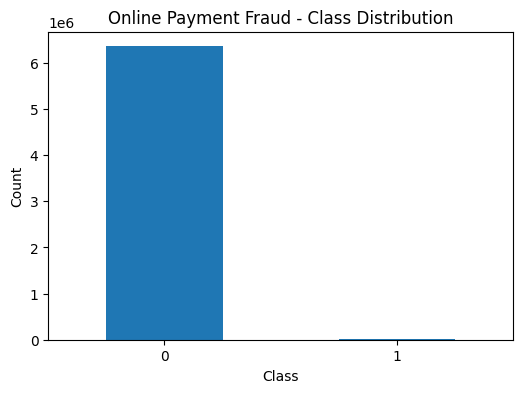

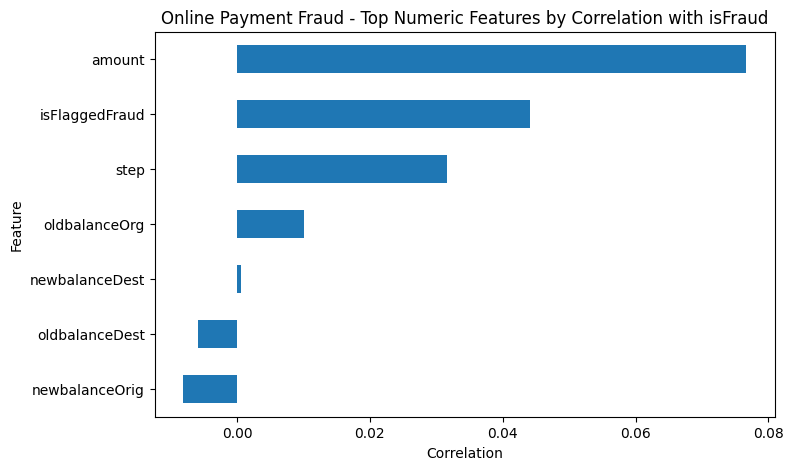

,correlation_with_target
amount,0.076688
isFlaggedFraud,0.044109
step,0.031578
oldbalanceOrg,0.010154
newbalanceOrig,-0.008148
oldbalanceDest,-0.005885
newbalanceDest,0.000535


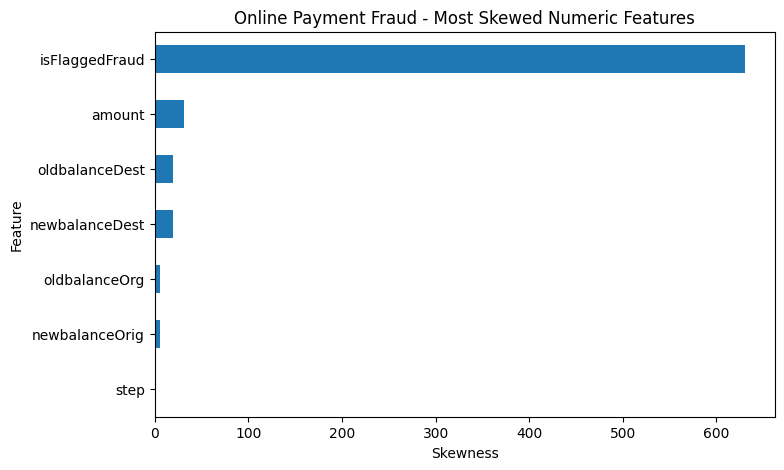

,skewness
isFlaggedFraud,630.603629
amount,30.993949
oldbalanceDest,19.921758
newbalanceDest,19.352302
oldbalanceOrg,5.249136
newbalanceOrig,5.176884
step,0.375177


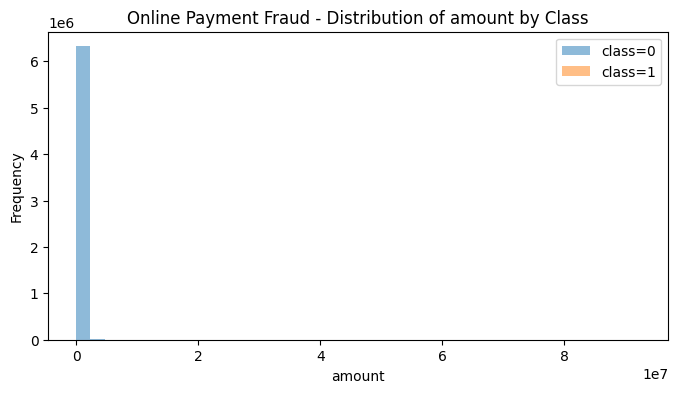


Online Payment Fraud - Fraud rate by type


,fraud_rate
type,
TRANSFER,0.007688
CASH_OUT,0.001840
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


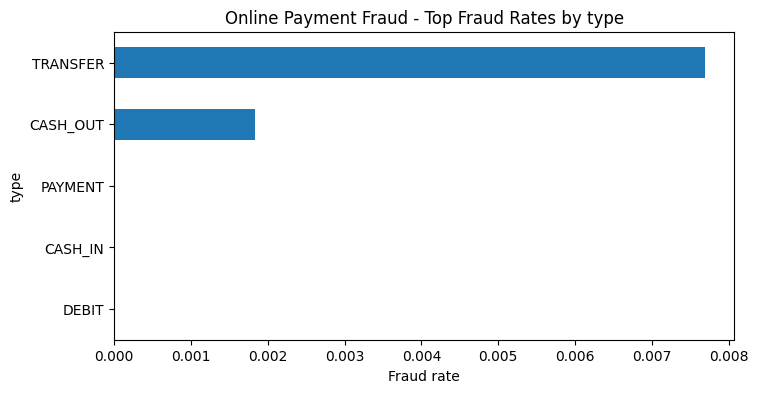


Online Payment Fraud - Fraud rate by nameOrig


,fraud_rate
nameOrig,
C1104869047,1.0
C1795788636,1.0
C1526831204,1.0
C1287154806,1.0
C165094398,1.0
C1659569966,1.0
C17491956,1.0
C1720178910,1.0
C1652591304,1.0


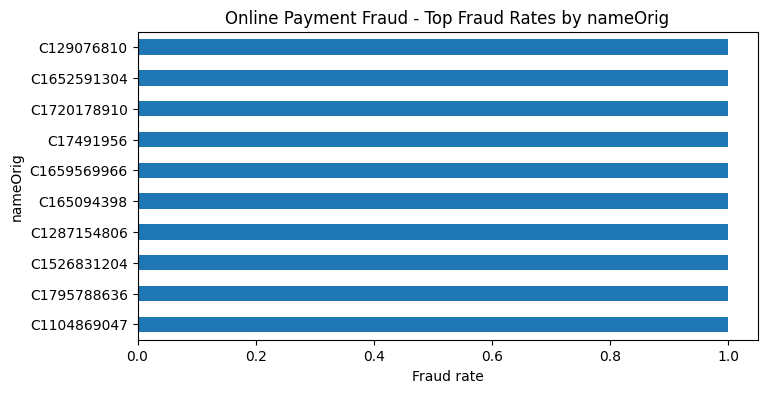


Online Payment Fraud - Fraud rate by nameDest


,fraud_rate
nameDest,
C1882736497,1.0
C489344681,1.0
C1092574222,1.0
C110798588,1.0
C538971825,1.0
C541074037,1.0
C1873232780,1.0
C1688196964,1.0
C364328277,1.0


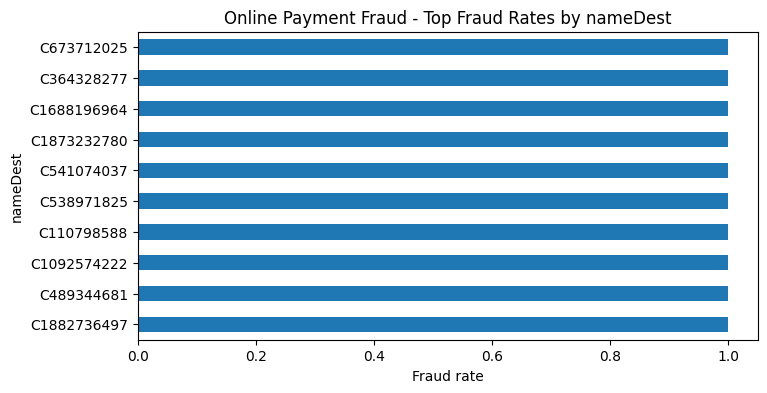

In [ ]:
online_info = DATASETS["Online Payment Fraud"]
online_df = load_dataset(online_info["path"])
basic_overview(online_df, "Online Payment Fraud", online_info["target"])
plot_class_distribution(online_df, online_info["target"], "Online Payment Fraud")
plot_top_numeric_correlations(online_df, online_info["target"], "Online Payment Fraud", top_n=10)
plot_top_skewed_features(online_df, online_info["target"], "Online Payment Fraud", top_n=10)
plot_numeric_feature_by_class(online_df, online_info["target"], "Online Payment Fraud", "amount")
show_top_categorical_fraud_rates(online_df, online_info["target"], "Online Payment Fraud", top_n=10)

### Online Payment Fraud Feature Interpretation

Fraud is mostly linked to specific transaction types, especially TRANSFER, with some cases in CASH_OUT. Other types like PAYMENT or DEBIT do not really show fraud, so transaction type is a useful feature for the model.

Higher transaction amounts are more associated with fraud. The data shows that larger transfers are more likely to be fraudulent, but there is still overlap with normal transactions, so amount alone is not enough to fully separate the classes.

The balance-related features do not clearly separate fraud and non-fraud on their own. Their individual correlations are low, so they are not strong features by themselves. However, they may still be useful when combined, since they represent how account balances change during a transaction.

The dataset also includes identifier columns like nameOrig and nameDest. These are just account IDs and do not represent real behaviour. If used directly, the model might just memorize specific accounts instead of learning patterns, which would not work well on new data. These columns should be removed or handled carefully.

Overall, fraud detection in this dataset depends on combining multiple features like transaction type, amount, and balance changes rather than relying on a single variable.

,dataset,model,accuracy,precision,recall,f1,roc_auc
2,Online Payment Fraud,XGBoost,0.999727,0.958274,0.824711,0.886490,0.997172
1,Online Payment Fraud,Random Forest,0.999702,0.978788,0.786366,0.872089,0.996224
0,Online Payment Fraud,Logistic Regression,0.951360,0.025230,0.974437,0.049187,0.994664


<Figure size 500x400 with 0 Axes>

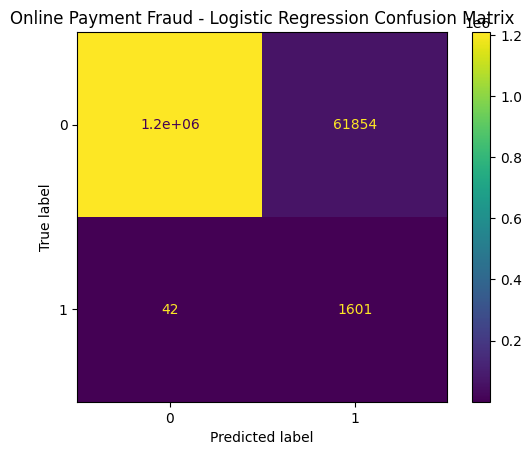

<Figure size 500x400 with 0 Axes>

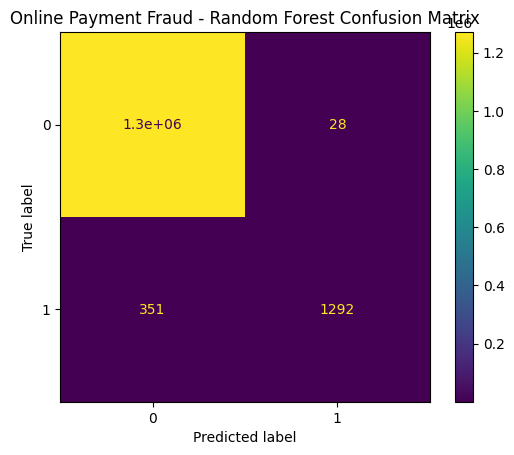

<Figure size 500x400 with 0 Axes>

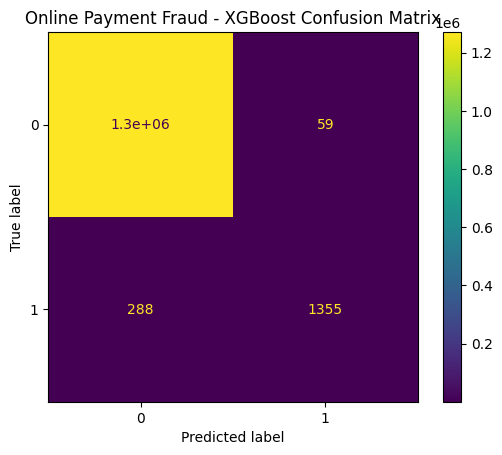

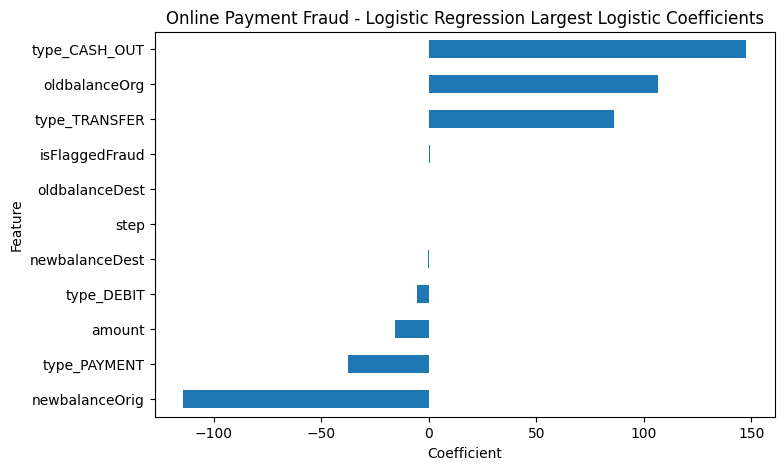

,coefficient
type_CASH_OUT,147.814632
newbalanceOrig,-114.374864
oldbalanceOrg,106.714677
type_TRANSFER,86.300457
type_PAYMENT,-37.324137
amount,-15.910588
type_DEBIT,-5.560424
isFlaggedFraud,0.565070
newbalanceDest,-0.482363
oldbalanceDest,0.354485


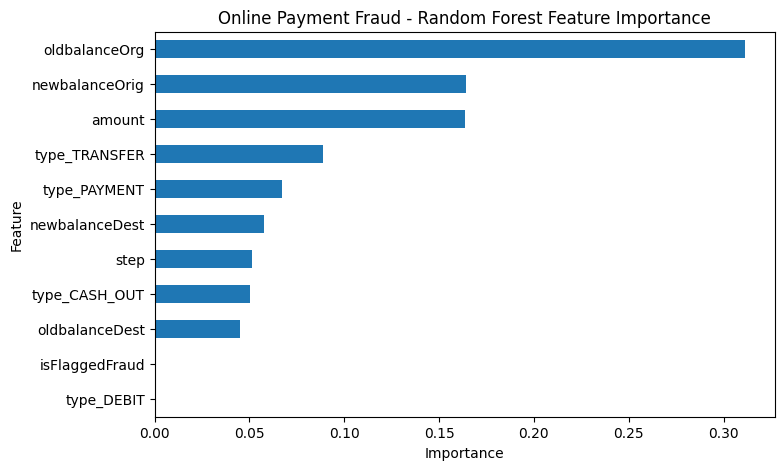

,importance
oldbalanceOrg,0.311366
newbalanceOrig,0.164170
amount,0.163628
type_TRANSFER,0.088676
type_PAYMENT,0.067237
newbalanceDest,0.057529
step,0.051392
type_CASH_OUT,0.050142
oldbalanceDest,0.045267
isFlaggedFraud,0.000393


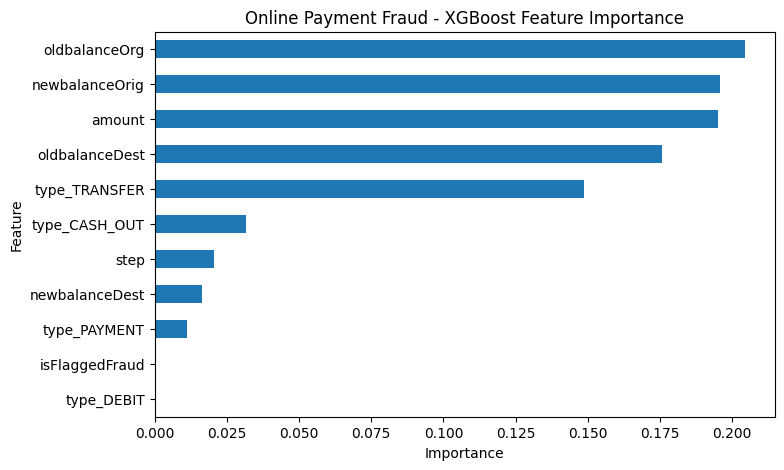

,importance
oldbalanceOrg,0.204502
newbalanceOrig,0.195747
amount,0.195184
oldbalanceDest,0.175810
type_TRANSFER,0.148775
type_CASH_OUT,0.031671
step,0.020629
newbalanceDest,0.016532
type_PAYMENT,0.011151
isFlaggedFraud,0.000000


In [ ]:
online_model_df = online_df.drop(columns=["nameOrig", "nameDest"], errors="ignore")

X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = preprocess_for_model(online_model_df, online_info["target"])
online_results, online_models = train_and_evaluate_models(
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, "Online Payment Fraud"
)
display(online_results)
plot_confusion_matrices(online_models, X_test, X_test_scaled, y_test, "Online Payment Fraud")

for model_name, obj in online_models.items():
    plot_feature_importance(obj["model"], X_train.columns, "Online Payment Fraud", model_name, top_n=15)

### Online Payment Fraud Model Evaluation

Tree-based models seem to benefit from combining features like balances and transaction type. From the feature importance, they are using multiple variables together rather than relying on just one, which helps them capture patterns that are not obvious from single features. Logistic Regression struggles more here. It still performs okay, but it makes more mistakes compared to the other models. This suggests that fraud in this dataset depends on more complex, non-linear relationships that a simple linear model cannot fully capture. Removing identifier-like columns (such as account IDs) makes the experiment more realistic. The model is forced to learn actual transaction patterns instead of memorizing specific accounts, so the results better reflect how it would perform on new, unseen data.

## Evaluating dataset 3: Bank Account Application Fraud Dataset

The third dataset represents a fraud detection problem in an application or onboarding context rather than individual transactions. It includes a mix of features such as demographic-style variables, device and session behavior, application-related actions, and other categorical business variables.

Unlike the previous datasets, this one contains a combination of numeric and categorical data, which means more preprocessing is required, such as encoding categorical features and handling different data types. The features are also more directly related to user behavior and system interaction, rather than just financial values.

This dataset is closer to what would be seen in a real business setting, where fraud detection depends on multiple types of signals working together. It allows models to learn patterns across user profiles, device usage, and application behavior, making it useful for building more practical and realistic fraud detection systems.

DATASET: Bank Account Application Fraud
Shape: (1000000, 32)

Columns:
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']

First 5 rows:


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0



Missing values per column:


fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
dtype: int64


Target distribution (counts):


fraud_bool
0    988971
1     11029
Name: count, dtype: int64


Target distribution (%):


fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64

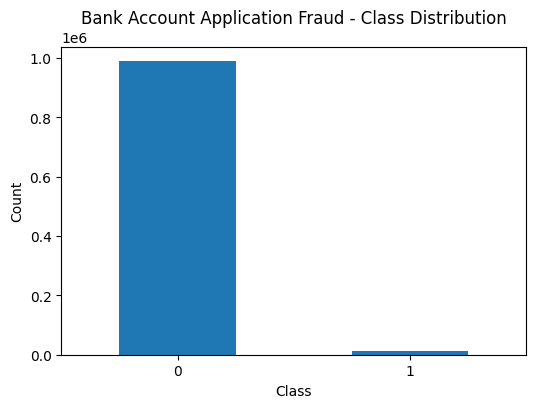

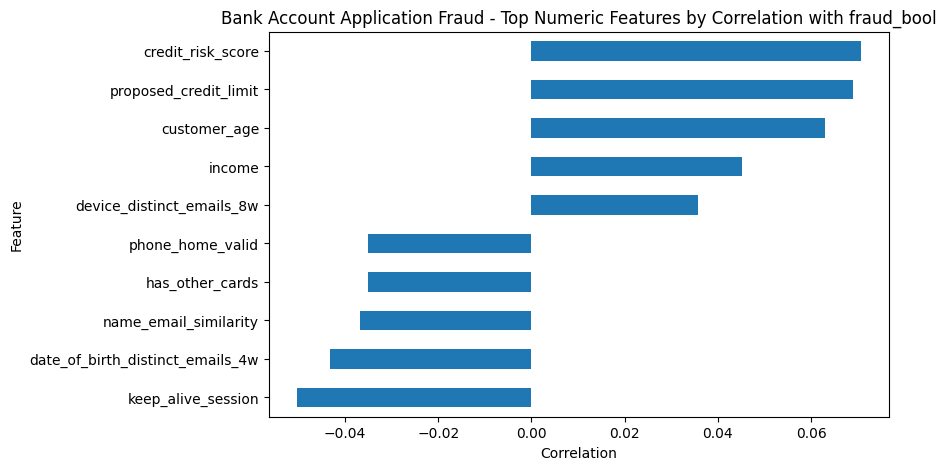

,correlation_with_target
credit_risk_score,0.070624
proposed_credit_limit,0.068907
customer_age,0.062959
keep_alive_session,-0.050296
income,0.045079
date_of_birth_distinct_emails_4w,-0.043224
name_email_similarity,-0.036720
device_distinct_emails_8w,0.035704
has_other_cards,-0.035156
phone_home_valid,-0.035128


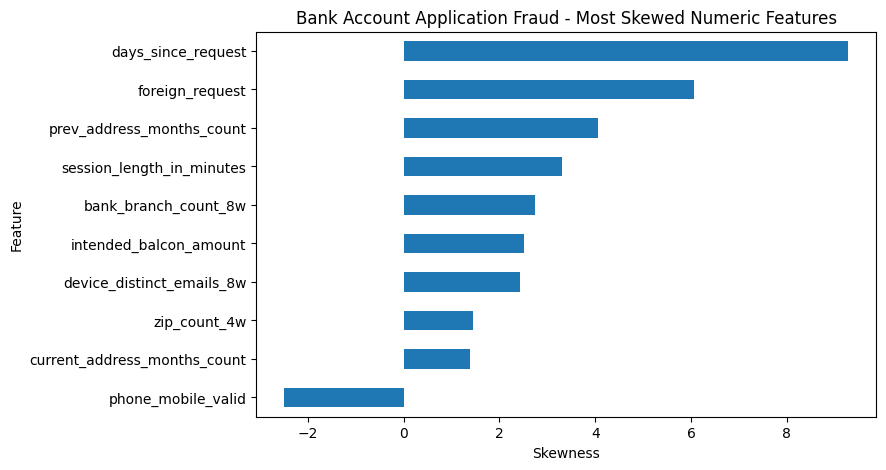

,skewness
days_since_request,9.278955
foreign_request,6.053306
prev_address_months_count,4.063888
session_length_in_minutes,3.304575
bank_branch_count_8w,2.747161
intended_balcon_amount,2.507173
phone_mobile_valid,-2.487616
device_distinct_emails_8w,2.430764
zip_count_4w,1.456657
current_address_months_count,1.386998


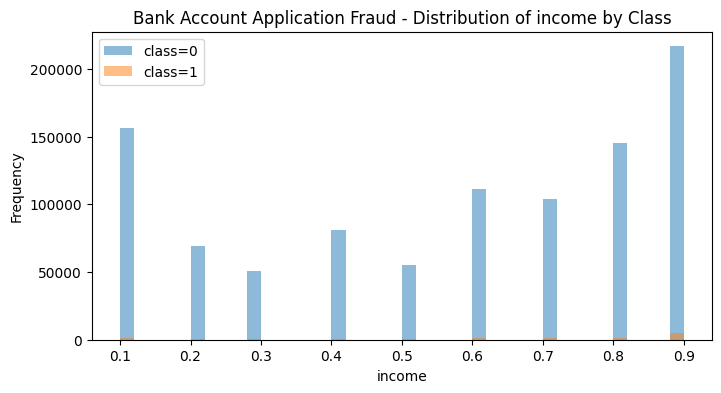

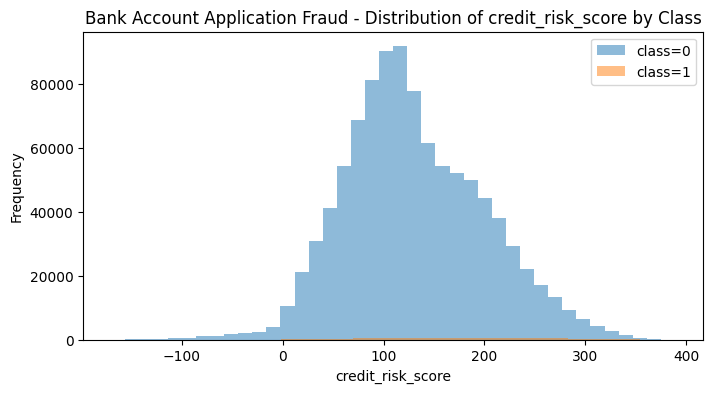

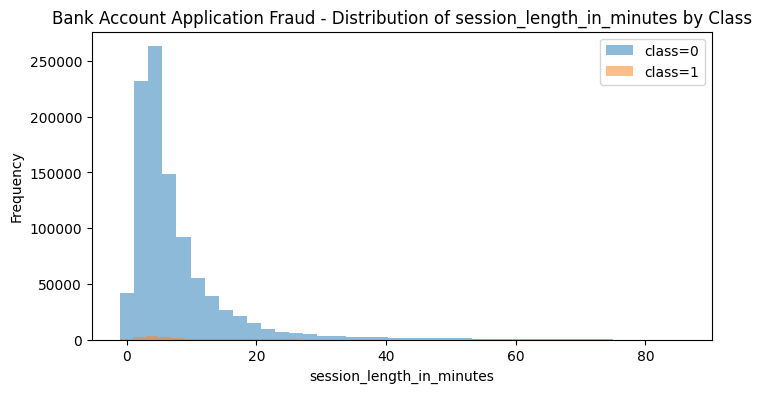

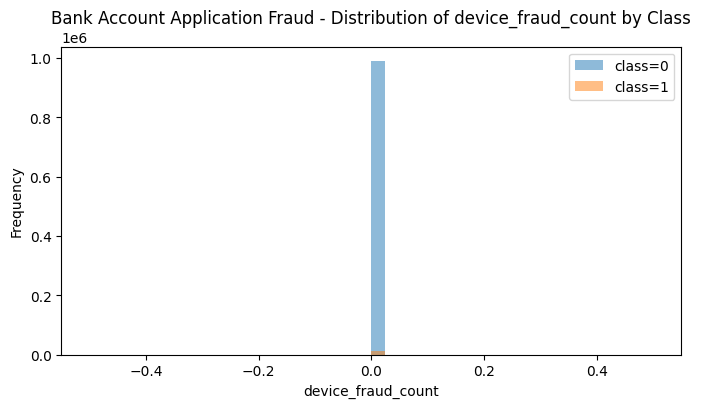


Bank Account Application Fraud - Fraud rate by payment_type


,fraud_rate
payment_type,
AC,0.016698
AB,0.011251
AD,0.010822
AA,0.005282
AE,0.003460


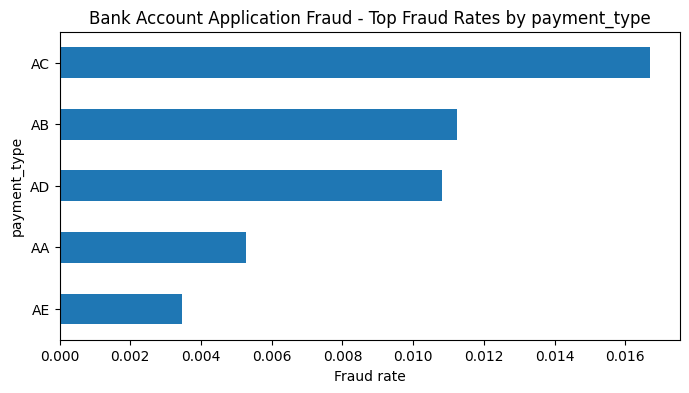


Bank Account Application Fraud - Fraud rate by employment_status


,fraud_rate
employment_status,
CC,0.024684
CG,0.015453
CA,0.012186
CB,0.006891
CD,0.003770
CE,0.002336
CF,0.001930


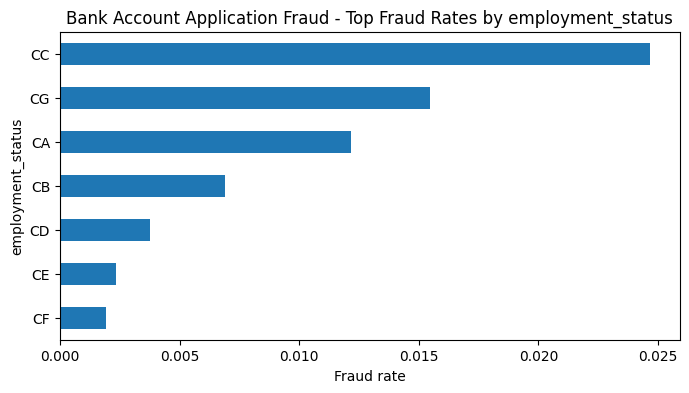


Bank Account Application Fraud - Fraud rate by housing_status


,fraud_rate
housing_status,
BA,0.037466
BD,0.008639
BC,0.006148
BB,0.006008
BF,0.004194
BG,0.003968
BE,0.003441


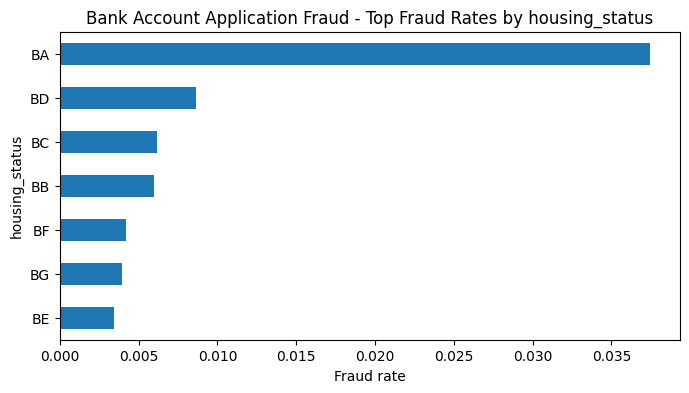


Bank Account Application Fraud - Fraud rate by source


,fraud_rate
source,
TELEAPP,0.015891
INTERNET,0.010994


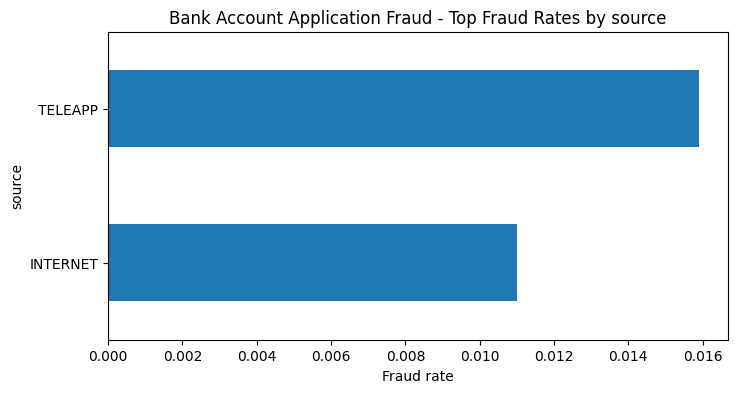


Bank Account Application Fraud - Fraud rate by device_os


,fraud_rate
device_os,
windows,0.024694
macintosh,0.013971
x11,0.011206
other,0.005760
linux,0.005155


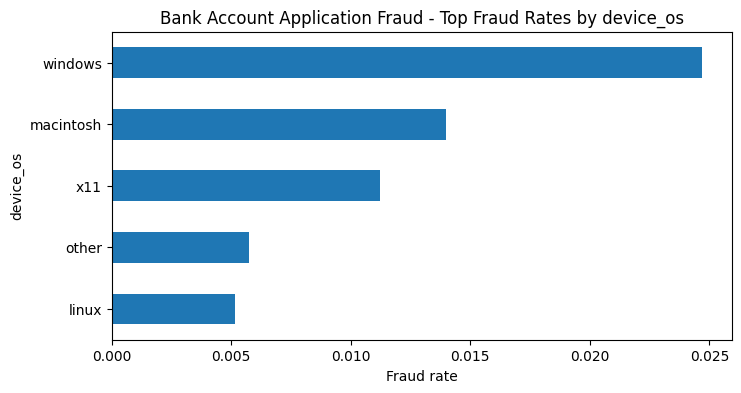

In [ ]:
bank_info = DATASETS["Bank Account Application Fraud"]
bank_df = load_dataset(bank_info["path"])
basic_overview(bank_df, "Bank Account Application Fraud", bank_info["target"])
plot_class_distribution(bank_df, bank_info["target"], "Bank Account Application Fraud")
plot_top_numeric_correlations(bank_df, bank_info["target"], "Bank Account Application Fraud", top_n=10)
plot_top_skewed_features(bank_df, bank_info["target"], "Bank Account Application Fraud", top_n=10)

# pick a few useful numeric features if they exist
for feature in ["income", "credit_risk_score", "session_length_in_minutes", "device_fraud_count"]:
    if feature in bank_df.columns:
        plot_numeric_feature_by_class(bank_df, bank_info["target"], "Bank Account Application Fraud", feature)

show_top_categorical_fraud_rates(bank_df, bank_info["target"], "Bank Account Application Fraud", top_n=10)

### Bank Account Application Fraud Feature Interpretation

Fraud is still very rare in this dataset based on the class distribution, so the same issue with imbalance applies here. Most applications are normal, with only a small number being fraudulent.

Some categorical features clearly show differences in fraud rates. For example, certain device operating systems like Windows have higher fraud rates compared to others. Similarly, categories like payment type, employment status, housing status, and application source all show variation, meaning these features can help the model separate fraud from non-fraud.

Looking at the numeric features, variables like credit_risk_score, proposed_credit_limit, income, and customer_age show some positive relationship with fraud, but the separation is not very strong. There is still a lot of overlap between fraud and non-fraud, so these features are useful but not enough on their own.

Some behavioral features such as device_distinct_emails_8w and keep_alive_session show negative relationships with fraud. This suggests that normal users tend to have more consistent or stable behavior, while fraud cases may look more irregular.

The distributions (like income, credit score, and session length) also show heavy overlap between classes. Fraud does not happen in a clearly separate range, so the model will need to combine multiple features to detect it.

Some features are highly skewed, such as days_since_request and foreign_request, meaning there are extreme values or rare events. These could be important signals for fraud but may need scaling or transformation.

In this case, no single feature clearly separates fraud. The dataset relies on combining demographic, behavioral, and categorical variables together to detect patterns, which makes the problem more complex but also more realistic.

,dataset,model,accuracy,precision,recall,f1,roc_auc
0,Bank Account Application Fraud,Logistic Regression,0.804640,0.043308,0.792384,0.082127,0.875921
2,Bank Account Application Fraud,XGBoost,0.988915,0.465839,0.033998,0.063371,0.895044
1,Bank Account Application Fraud,Random Forest,0.988970,0.500000,0.000907,0.001810,0.851631


<Figure size 500x400 with 0 Axes>

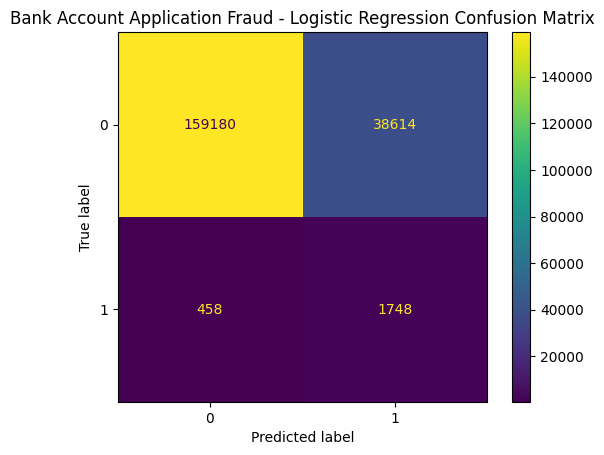

<Figure size 500x400 with 0 Axes>

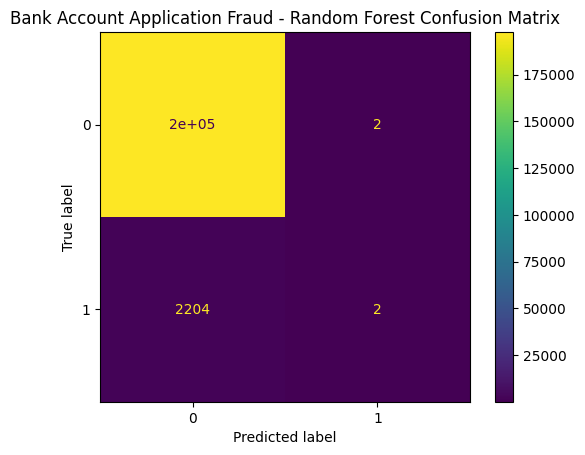

<Figure size 500x400 with 0 Axes>

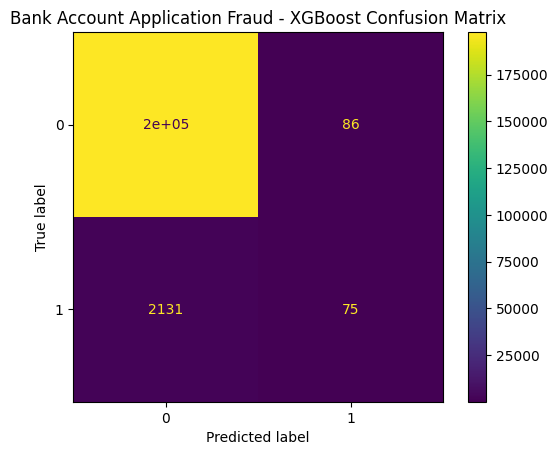

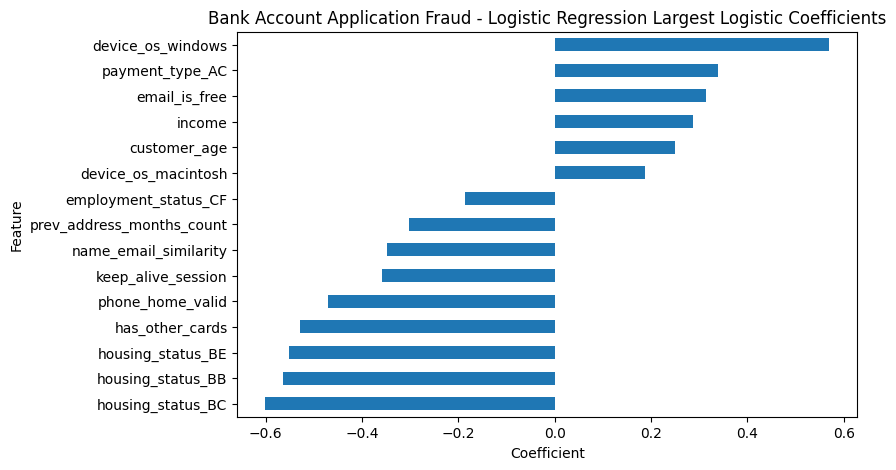

,coefficient
housing_status_BC,-0.600259
device_os_windows,0.569562
housing_status_BB,-0.563800
housing_status_BE,-0.551891
has_other_cards,-0.527763
phone_home_valid,-0.469474
keep_alive_session,-0.357789
name_email_similarity,-0.348804
payment_type_AC,0.339876
email_is_free,0.313069


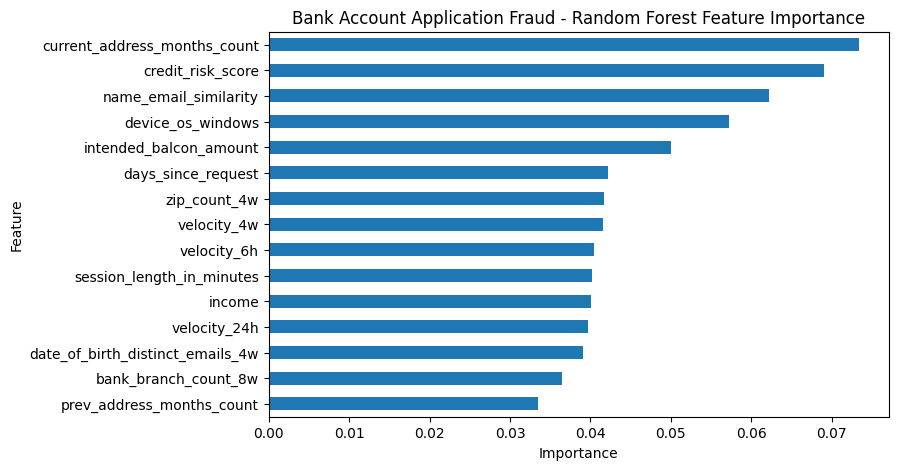

,importance
current_address_months_count,0.073420
credit_risk_score,0.069068
name_email_similarity,0.062195
device_os_windows,0.057218
intended_balcon_amount,0.050007
days_since_request,0.042122
zip_count_4w,0.041658
velocity_4w,0.041588
velocity_6h,0.040466
session_length_in_minutes,0.040225


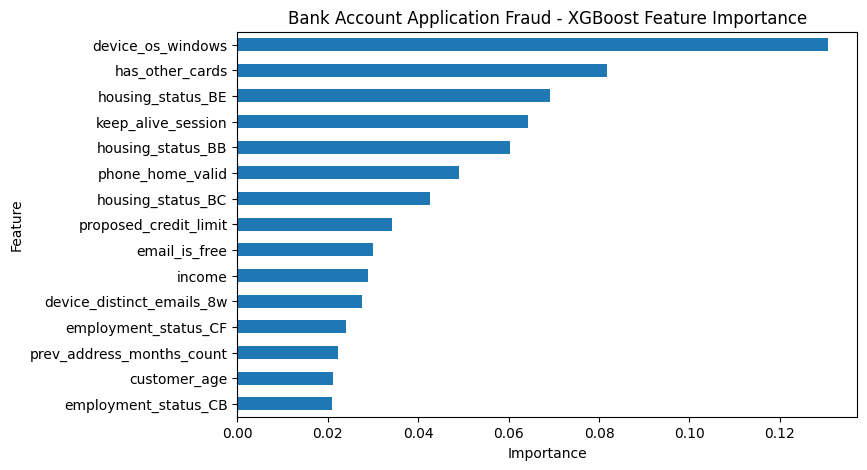

,importance
device_os_windows,0.130588
has_other_cards,0.081672
housing_status_BE,0.069101
keep_alive_session,0.064314
housing_status_BB,0.060351
phone_home_valid,0.048928
housing_status_BC,0.042570
proposed_credit_limit,0.034312
email_is_free,0.029921
income,0.028872


In [ ]:
X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = preprocess_for_model(bank_df, bank_info["target"])
bank_results, bank_models = train_and_evaluate_models(
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, "Bank Account Application Fraud"
)
display(bank_results)
plot_confusion_matrices(bank_models, X_test, X_test_scaled, y_test, "Bank Account Application Fraud")

for model_name, obj in bank_models.items():
    plot_feature_importance(obj["model"], X_train.columns, "Bank Account Application Fraud", model_name, top_n=15)

### Bank Account Application Fraud Model Evaluation

Categorical business variables do help the model. From the coefficients and feature importance, things like device_os, payment_type, housing_status, and employment_status show up as important. This means the model is able to use these categories to find patterns in fraud, not just numeric values. Application and device-related features seem to create stronger fraud signals than simple financial variables. Features like device_os, name_email_similarity, session behavior, and email-related variables appear more important than things like income alone. This suggests fraud is more linked to behavior and application patterns rather than just financial values. A more flexible model (like Random Forest or XGBoost) captures these mixed-feature interactions better. Logistic Regression struggles more and makes more mistakes, while the tree-based models can combine different types of features together. This helps them pick up more complex patterns across categorical and numeric variables.

## Summary

In [ ]:
all_results = pd.concat([credit_results, online_results, bank_results], ignore_index=True)
display(all_results.sort_values(["dataset", "f1"], ascending=[True, False]))

,dataset,model,accuracy,precision,recall,f1,roc_auc
6,Bank Account Application Fraud,Logistic Regression,0.804640,0.043308,0.792384,0.082127,0.875921
7,Bank Account Application Fraud,XGBoost,0.988915,0.465839,0.033998,0.063371,0.895044
8,Bank Account Application Fraud,Random Forest,0.988970,0.500000,0.000907,0.001810,0.851631
0,Credit Card Fraud,XGBoost,0.999579,0.940476,0.806122,0.868132,0.979476
1,Credit Card Fraud,Random Forest,0.999526,0.961039,0.755102,0.845714,0.957189
2,Credit Card Fraud,Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972083
3,Online Payment Fraud,XGBoost,0.999727,0.958274,0.824711,0.886490,0.997172
4,Online Payment Fraud,Random Forest,0.999702,0.978788,0.786366,0.872089,0.996224
5,Online Payment Fraud,Logistic Regression,0.951360,0.025230,0.974437,0.049187,0.994664


<Figure size 1000x500 with 0 Axes>

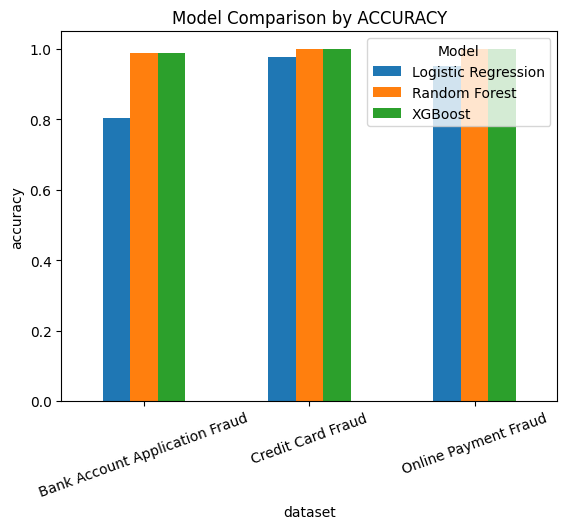

<Figure size 1000x500 with 0 Axes>

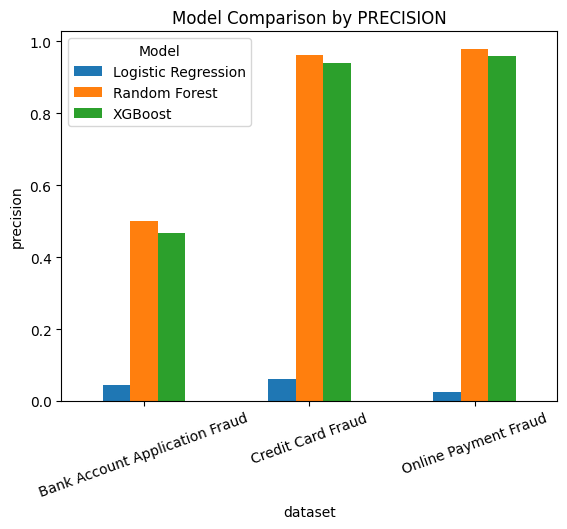

<Figure size 1000x500 with 0 Axes>

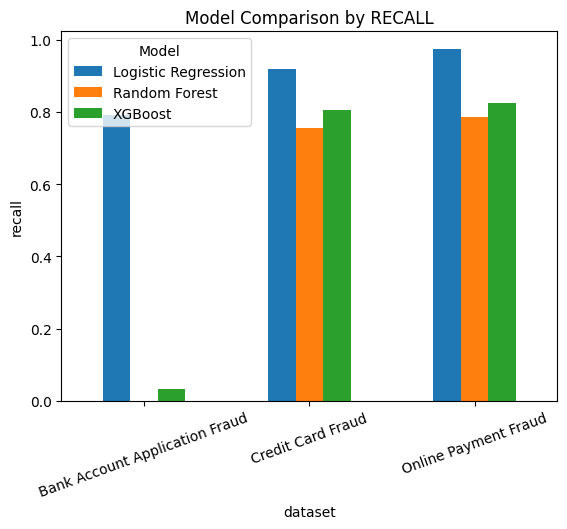

<Figure size 1000x500 with 0 Axes>

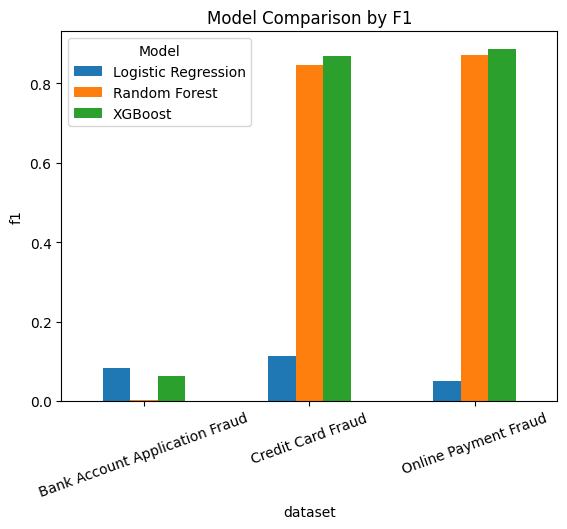

<Figure size 1000x500 with 0 Axes>

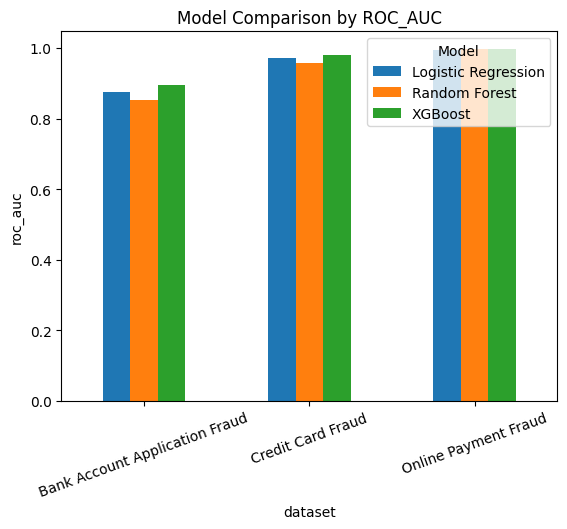

In [ ]:
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    plt.figure(figsize=(10, 5))
    pivot = all_results.pivot(index="dataset", columns="model", values=metric)
    pivot.plot(kind="bar")
    plt.title(f"Model Comparison by {metric.upper()}")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.legend(title="Model")
    plt.show()